In [12]:
import pandas as pd
ltv_final = pd.read_csv("Customer_LTV_Summary.csv")
Sales = pd.read_csv("../LTV-Capstone-Project/Data/Online_Sales.csv")


In [13]:
ltv_final.head(2)

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_ltv_6m,gender,location,tenure_months
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20


In [14]:
Sales.head(2)

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,avg_price,delivery_charges,coupon_status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used


In [15]:
# Convert Coupon_Status to numeric (1 for used, 0 for not used)
Sales['coupon_status'] = Sales['coupon_status'].map({'Used': 1, 'Not Used': 0})

# Average coupon usage rate per customer (0 to 1)
coupon_usage = Sales.groupby('customer_id')['coupon_status'].mean().reset_index()
coupon_usage.columns = ['customer_id', 'coupon_usage_rate']


In [16]:
# Flag if each transaction is in high season 
Sales['high_season'] = pd.to_datetime(Sales['transaction_date'].astype(str)).dt.month.isin([11, 12])

# Check if each customer had any transaction in high season
season_flag = Sales.groupby('customer_id')['high_season'].max().reset_index()

In [17]:
ltv_final.head()

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_ltv_6m,gender,location,tenure_months
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20
2,12348,1.0,119.0,192.0,693.731,0.577773,1187.344186,686.015648,M,California,39
3,12350,0.0,0.0,17.0,0.000,0.914834,1265.594052,1157.807941,M,California,25
4,12356,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,Illinois,31


In [18]:
# Merge coupon usage
ltv_final = ltv_final.merge(coupon_usage, on='customer_id', how='left')

# Merge seasonality
ltv_final = ltv_final.merge(season_flag, on='customer_id', how='left')

# Fill any missing values
ltv_final['coupon_usage_rate'] = ltv_final['coupon_usage_rate'].fillna(0)
ltv_final['high_season'] = ltv_final['high_season'].fillna(False)

We grouped customers by coupon usage and seasonal activity, then compared average LTV. Incrementality measures the additional impact caused directly by a marketing action or campaign — essentially, the lift or incremental gain beyond what would have happened anyway without the marketing.
For example:
If customers who used coupons have a higher LTV, the question is:
Is that increase caused by the coupon, or would those customers have bought just as much anyway?
Incrementality tries to isolate the causal effect of marketing (coupons, ads, seasonality, etc.) on sales, LTV, or other KPIs.

Below we grouped customers by coupon usage and seasonal activity, then compared average LTV

In [19]:
# LTV by Coupon Exposure
ltv_final.groupby('coupon_usage_rate')['predicted_ltv_6m'].mean()

coupon_usage_rate
0.000000    549.864476
0.142857    594.015078
0.166667    191.353170
0.200000    846.447143
0.250000    627.522860
               ...    
0.923077    368.069578
0.928571    350.571204
0.937500    134.234391
0.941176    559.171604
1.000000    582.534203
Name: predicted_ltv_6m, Length: 239, dtype: float64

In [20]:
# LTV by by Seasonality
ltv_final.groupby('high_season')['predicted_ltv_6m'].mean()

high_season
False     537.199177
True     1799.741663
Name: predicted_ltv_6m, dtype: float64

C:\Users\Lukas\AppData\Local\Temp\ipykernel_26168\883921541.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ltv_final, x='coupon_bin', y='predicted_ltv_6m', palette='Blues_d')


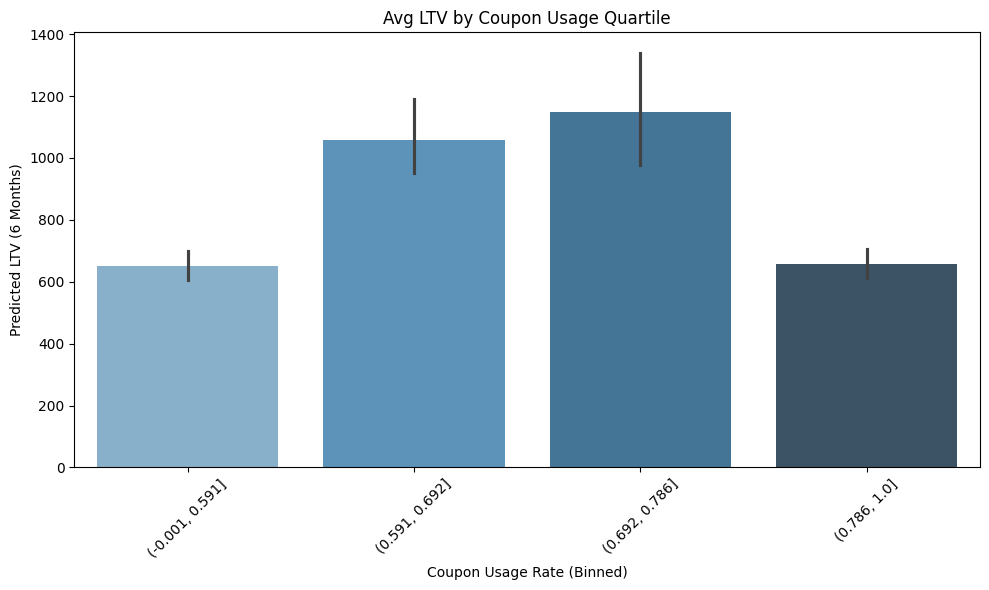

In [23]:
# These bar plots will  show whether coupon usage and holiday season purchases are associated with higher predicted LTV

#Avg LTV by Coupon Usage Quartile

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# Bin coupon usage into 4 groups (0 to high)
ltv_final['coupon_bin'] = pd.qcut(ltv_final['coupon_usage_rate'], q=4)

plt.figure(figsize=(10, 6))
sns.barplot(data=ltv_final, x='coupon_bin', y='predicted_ltv_6m', palette='Blues_d')
plt.title('Avg LTV by Coupon Usage Quartile')
plt.xlabel('Coupon Usage Rate (Binned)')
plt.ylabel('Predicted LTV (6 Months)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Lukas\AppData\Local\Temp\ipykernel_26168\3960945311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ltv_final, x='high_season', y='predicted_ltv_6m', palette='Set2')


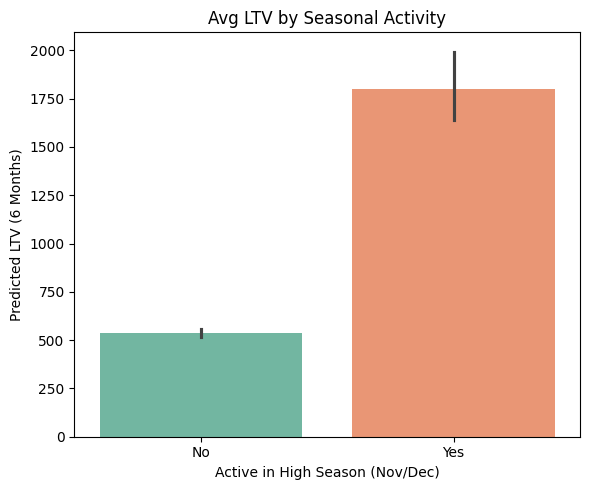

In [24]:
#Average LTV: Seasonal vs. Non-Seasonal Customers
plt.figure(figsize=(6, 5))
sns.barplot(data=ltv_final, x='high_season', y='predicted_ltv_6m', palette='Set2')
plt.title('Avg LTV by Seasonal Activity')
plt.xlabel('Active in High Season (Nov/Dec)')
plt.ylabel('Predicted LTV (6 Months)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_26168\902315620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered, x='location', y='predicted_ltv_6m', palette='coolwarm')


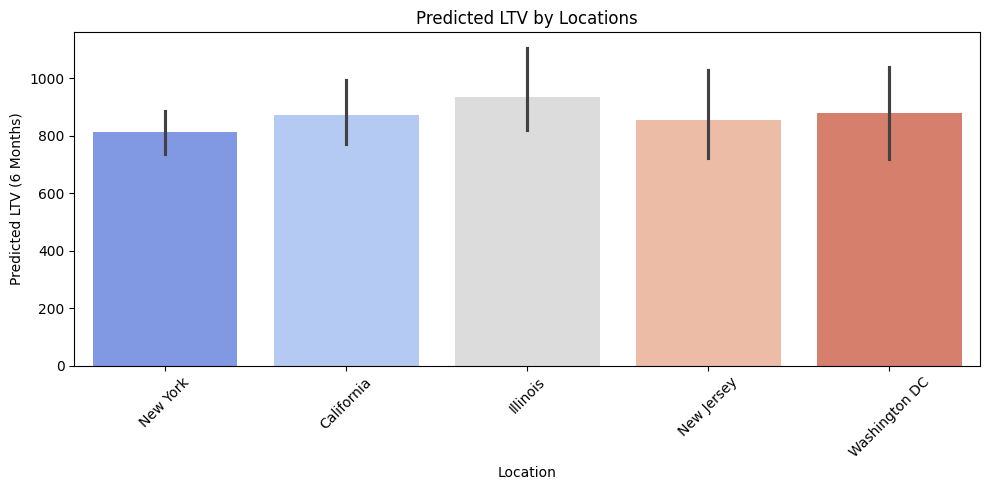

In [26]:
#LTV by Location
plt.figure(figsize=(10, 5))
top_locations = ltv_final['location'].value_counts().nlargest(10).index
filtered = ltv_final[ltv_final['location'].isin(top_locations)]

sns.barplot(data=filtered, x='location', y='predicted_ltv_6m', palette='coolwarm')
plt.title('Predicted LTV by Locations')
plt.ylabel('Predicted LTV (6 Months)')
plt.xlabel('Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_26168\4240173170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ltv_final, x='gender', y='predicted_ltv_6m', palette='pastel')


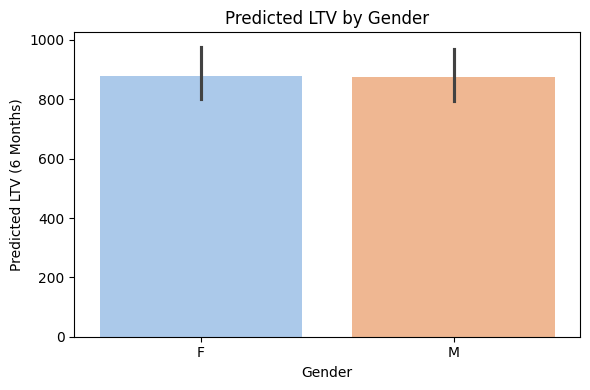

In [27]:
#LTV by Gender
plt.figure(figsize=(6, 4))
sns.barplot(data=ltv_final, x='gender', y='predicted_ltv_6m', palette='pastel')
plt.title('Predicted LTV by Gender')
plt.ylabel('Predicted LTV (6 Months)')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

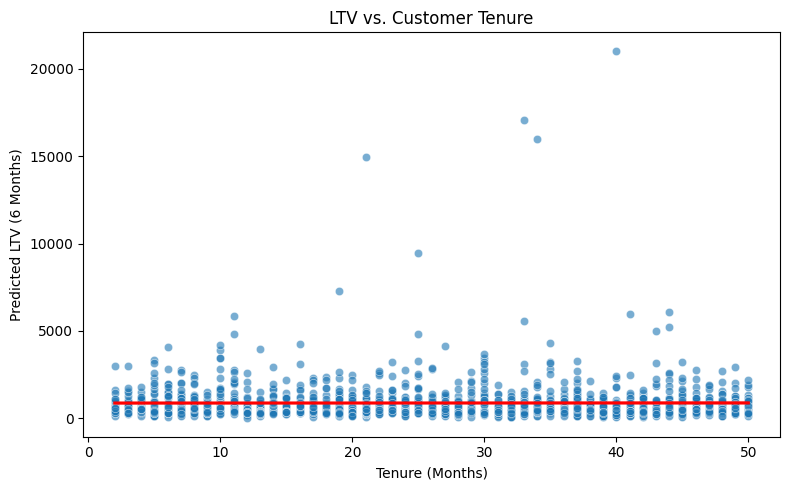

In [29]:
#LTV vs. Tenure (Months)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=ltv_final, x='tenure_months', y='predicted_ltv_6m', alpha=0.6)
sns.regplot(data=ltv_final, x='tenure_months', y='predicted_ltv_6m', scatter=False, color='red')
plt.title('LTV vs. Customer Tenure')
plt.ylabel('Predicted LTV (6 Months)')
plt.xlabel('Tenure (Months)')
plt.tight_layout()
plt.show()

In [30]:
# Generate dataframes for export
#  1. LTV by Gender
ltv_by_gender = ltv_final.groupby('gender')['predicted_ltv_6m'].mean().reset_index()

# 2. LTV by Top 10 Locations
top_locations = ltv_final['location'].value_counts().nlargest(10).index
filtered_location = ltv_final[ltv_final['location'].isin(top_locations)]
ltv_by_location = filtered_location.groupby('location')['predicted_ltv_6m'].mean().reset_index()

# 3. LTV by Tenure
ltv_by_tenure = ltv_final.groupby('tenure_months')['predicted_ltv_6m'].mean().reset_index()

In [31]:
ltv_by_gender.to_csv('ltv_by_gender.csv', index=False)
ltv_by_location.to_csv('ltv_by_location_top10.csv', index=False)
ltv_by_tenure.to_csv('ltv_by_tenure.csv', index=False)

In [32]:
# Average predicted LTV by coupon usage quartiles and export it as a CSV for Tableau

# Create coupon usage quartiles
ltv_final['coupon_usage_quartile'] = pd.qcut(ltv_final['coupon_usage_rate'], 4, labels=False)

# Calculate average predicted LTV per quartile
ltv_by_coupon_quartile = ltv_final.groupby('coupon_usage_quartile')['predicted_ltv_6m'].mean().reset_index()

# Optionally, rename quartiles for clarity
ltv_by_coupon_quartile['coupon_usage_quartile'] = ltv_by_coupon_quartile['coupon_usage_quartile'].map({
    0: 'Q1 (Lowest)',
    1: 'Q2',
    2: 'Q3',
    3: 'Q4 (Highest)'
})

ltv_by_coupon_quartile.to_csv('ltv_by_coupon_quartile.csv', index=False)

In [33]:
# LTV by seasonal activity export data to CSV for Tableau and DBeaver

ltv_by_season = ltv_final.groupby('high_season')['predicted_ltv_6m'].mean().reset_index()

# Rename for clarity
ltv_by_season['high_season'] = ltv_by_season['high_season'].map({False: 'Non-Seasonal', True: 'Seasonal'})

ltv_by_season.to_csv('ltv_by_seasonal_activity.csv', index=False)